In [14]:

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.ar_model import AutoReg


     CELL 1: AR(1) BENCHMARK (WTI ONLY)
RMSE : 0.090935 | MAE  : 0.065458
R^2  : 0.069036 | Adj R^2: 0.067084
AIC  : -931.5678 | BIC  : -919.0527


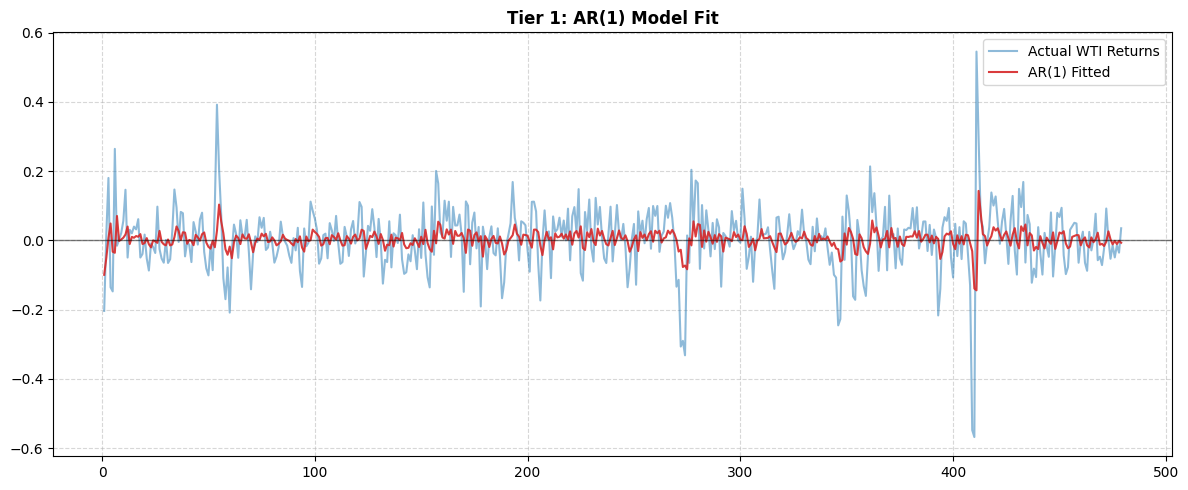

In [15]:
#AR(1) with just wti_ret 

#Load Data
file_path = Path('data') / 'final_data.csv'
df = pd.read_csv(file_path)
y = df['wti_ret'].dropna()

#Fit AR(1)
ar1_model = AutoReg(y, lags=1, old_names=False).fit()

#Metrics
fitted_vals = ar1_model.fittedvalues
y_aligned = y.loc[fitted_vals.index]
residuals = y_aligned - fitted_vals

rmse = np.sqrt(np.mean(residuals**2))
mae = np.mean(np.abs(residuals))

ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_aligned - np.mean(y_aligned))**2)
r_squared = 1 - (ss_res / ss_tot)

n, p = len(y_aligned), 1
adj_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)

#Output Results

print("     CELL 1: AR(1) BENCHMARK (WTI ONLY)")
print(f"RMSE : {rmse:.6f} | MAE  : {mae:.6f}")
print(f"R^2  : {r_squared:.6f} | Adj R^2: {adj_r_squared:.6f}")
print(f"AIC  : {ar1_model.aic:.4f} | BIC  : {ar1_model.bic:.4f}")


#Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_aligned.index, y_aligned, label='Actual WTI Returns', color='#1f77b4', alpha=0.5)
ax.plot(fitted_vals.index, fitted_vals, label='AR(1) Fitted', color='#d62728', alpha=0.9)
ax.set_title('Tier 1: AR(1) Model Fit', fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
ax.axhline(0, color='black', linewidth=1, alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

  CELL 2: ADL(1,1) BENCHMARK (WTI + TB3MS)
RMSE : 0.090477 | MAE  : 0.065398
R^2  : 0.078390 | Adj R^2: 0.074518
AIC  : -936.4053 | BIC  : -923.8902


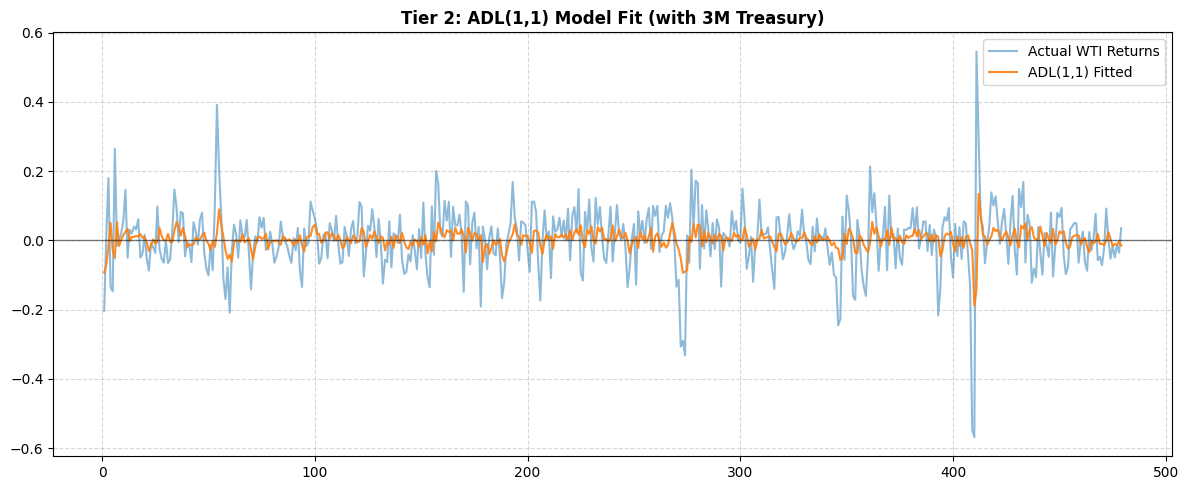

In [16]:

#ADL(1,1) - wti_ret and tb3ms
#Load Data
file_path = Path('data') / 'final_data.csv'
df = pd.read_csv(file_path)

#Shift Data for Forecasting 
model_data = pd.DataFrame({
    'Y_t': df['wti_ret'],
    'Y_t_minus_1': df['wti_ret'].shift(1),
    'TB3MS_t_minus_1': df['TB3MS'].shift(1)
}).dropna()

#Fit ADL(1,1)
X = sm.add_constant(model_data[['Y_t_minus_1', 'TB3MS_t_minus_1']])
Y = model_data['Y_t']
adl_model = sm.OLS(Y, X).fit()

#Metrics
fitted_vals = adl_model.fittedvalues
residuals = Y - fitted_vals

rmse = np.sqrt(np.mean(residuals**2))
mae = np.mean(np.abs(residuals))

ss_res = np.sum(residuals**2)
ss_tot = np.sum((Y - np.mean(Y))**2)
r_squared = 1 - (ss_res / ss_tot)

n, p = len(Y), 2
adj_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)

#Output Results

print("  CELL 2: ADL(1,1) BENCHMARK (WTI + TB3MS)")
print(f"RMSE : {rmse:.6f} | MAE  : {mae:.6f}")
print(f"R^2  : {r_squared:.6f} | Adj R^2: {adj_r_squared:.6f}")
print(f"AIC  : {adl_model.aic:.4f} | BIC  : {adl_model.bic:.4f}")


#Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(Y.index, Y, label='Actual WTI Returns', color='#1f77b4', alpha=0.5)
ax.plot(fitted_vals.index, fitted_vals, label='ADL(1,1) Fitted', color='#ff7f0e', alpha=0.9)
ax.set_title('Tier 2: ADL(1,1) Model Fit (with 3M Treasury)', fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
ax.axhline(0, color='black', linewidth=1, alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

 CELL 3: FULL ADL BENCHMARK (8 COVARIATES)
RMSE : 0.089135 | MAE  : 0.064700
R^2  : 0.105532 | Adj R^2: 0.088367
AIC  : -936.7239 | BIC  : -895.0069


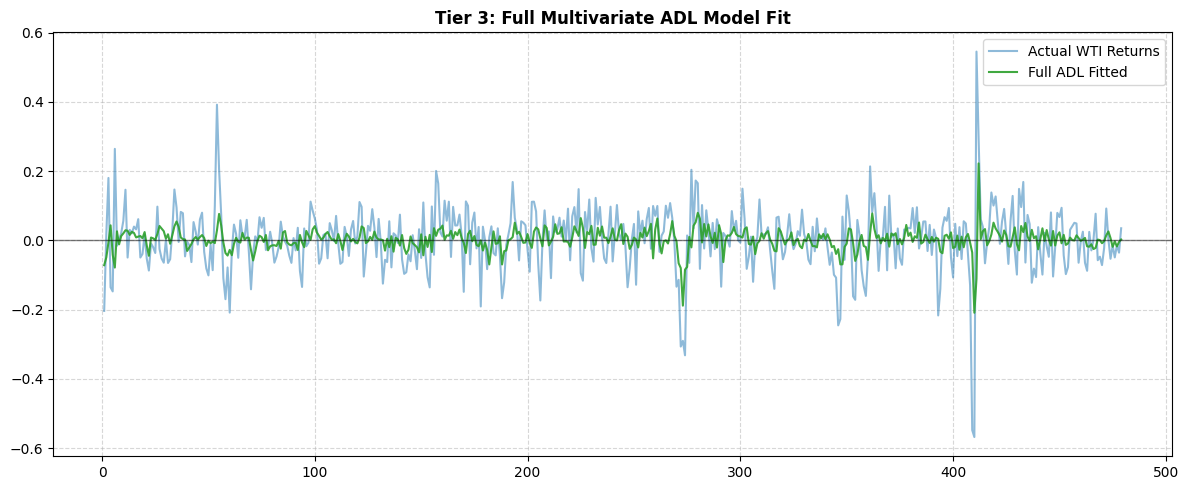

In [17]:

#full ADL with all 8 covariates
#Load Data
file_path = Path('data') / 'final_data.csv'
df = pd.read_csv(file_path)


#Shift Data for all 8 covariates
target = 'wti_ret'
all_features = ['wti_ret', 'AUD_USD_ret', 'CAD_USD_ret', 'NZD_USD_ret', 
                'ZAR_USD_ret', 'CPI', 'TB3MS', 'M1', 'M2']

model_data = pd.DataFrame({'Y_t': df[target]})
for feature in all_features:
    model_data[f'{feature}_t_minus_1'] = df[feature].shift(1)
model_data = model_data.dropna()

#Fit Full ADL
X_cols = [f'{feat}_t_minus_1' for feat in all_features]
X = sm.add_constant(model_data[X_cols])
Y = model_data['Y_t']
full_adl_model = sm.OLS(Y, X).fit()

#Metrics
fitted_vals = full_adl_model.fittedvalues
residuals = Y - fitted_vals

rmse = np.sqrt(np.mean(residuals**2))
mae = np.mean(np.abs(residuals))

ss_res = np.sum(residuals**2)
ss_tot = np.sum((Y - np.mean(Y))**2)
r_squared = 1 - (ss_res / ss_tot)

n, p = len(Y), len(X_cols)
adj_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)

#Output Results
print("="*50)
print(" CELL 3: FULL ADL BENCHMARK (8 COVARIATES)")
print("="*50)
print(f"RMSE : {rmse:.6f} | MAE  : {mae:.6f}")
print(f"R^2  : {r_squared:.6f} | Adj R^2: {adj_r_squared:.6f}")
print(f"AIC  : {full_adl_model.aic:.4f} | BIC  : {full_adl_model.bic:.4f}")
print("="*50)

#Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(Y.index, Y, label='Actual WTI Returns', color='#1f77b4', alpha=0.5)
ax.plot(fitted_vals.index, fitted_vals, label='Full ADL Fitted', color='#2ca02c', alpha=0.9)
ax.set_title('Tier 3: Full Multivariate ADL Model Fit', fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
ax.axhline(0, color='black', linewidth=1, alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()